# Baseball Strike Zones
**Objective**: Use an SVM trained using a baseball dataset to find the decision boundary of the strike zone.

In [35]:
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from svm_visualisation import draw_boundary
import pandas as pd

In [36]:
aaron_judge = pd.read_csv('aaron_judge.csv')
david_ortiz = pd.read_csv('david_ortiz.csv')
jose_altuve = pd.read_csv('jose_altuve.csv')

## Create the Labels

In [37]:
# 1. Look at all of the features of a pitch.
print('Pitch features:\n', aaron_judge.columns)

Pitch features:
 Index(['pitch_type', 'game_date', 'release_speed', 'release_pos_x',
       'release_pos_z', 'player_name', 'batter', 'pitcher', 'events',
       'description', 'spin_dir', 'spin_rate_deprecated',
       'break_angle_deprecated', 'break_length_deprecated', 'zone', 'des',
       'game_type', 'stand', 'p_throws', 'home_team', 'away_team', 'type',
       'hit_location', 'bb_type', 'balls', 'strikes', 'game_year', 'pfx_x',
       'pfx_z', 'plate_x', 'plate_z', 'on_3b', 'on_2b', 'on_1b',
       'outs_when_up', 'inning', 'inning_topbot', 'hc_x', 'hc_y',
       'tfs_deprecated', 'tfs_zulu_deprecated', 'pos2_person_id', 'umpire',
       'sv_id', 'vx0', 'vy0', 'vz0', 'ax', 'ay', 'az', 'sz_top', 'sz_bot',
       'hit_distance_sc', 'launch_speed', 'launch_angle', 'effective_speed',
       'release_spin_rate', 'release_extension', 'game_pk', 'pos1_person_id',
       'pos2_person_id.1', 'pos3_person_id', 'pos4_person_id',
       'pos5_person_id', 'pos6_person_id', 'pos7_person_id', 

In [38]:
# 2. See the different values the 'description' feature could have.
print('Description values:\n', aaron_judge.description.unique())

Description values:
 <ArrowStringArray>
[        'swinging_strike',           'called_strike',
                    'ball',     'hit_into_play_score',
                    'foul',            'blocked_ball',
           'hit_into_play',    'hit_into_play_no_out',
 'swinging_strike_blocked',                'foul_tip',
            'hit_by_pitch']
Length: 11, dtype: str


In [39]:
# 3. Look at the unique values stored in the 'type' feature.
print('Type values:\n', aaron_judge.type.unique())

Type values:
 <ArrowStringArray>
['S', 'B', 'X']
Length: 3, dtype: str


**Glossary:**
* ```B```: ball
* ```S```: strike
* ```X```: neither (could be an out or a hit)

In [40]:
# 4. Use the 'type' feature to label data points.
print('Assigning values to strikes and balls ...')
aaron_judge['type'] = aaron_judge['type'].map({'B':0, 'S':1})

Assigning values to strikes and balls ...


In [41]:
# 5. Check to see if the labelling worked.
print('New type values:\n', aaron_judge['type'])

New type values:
 0       1.0
1       1.0
2       1.0
3       0.0
4       1.0
       ... 
2984    1.0
2985    NaN
2986    0.0
2987    0.0
2988    NaN
Name: type, Length: 2989, dtype: float64


## Plot the Pitches

In [42]:
# 6. Look at the ball locations in the x-axis.
print('Here\'s how far left or right from the centre of home plate the pitches were:\n', aaron_judge['plate_x'])

Here's how far left or right from the centre of home plate the pitches were:
 0       1.0150
1       0.4546
2       0.0957
3       1.5161
4       0.0764
         ...  
2984   -0.3738
2985   -0.2953
2986    1.4094
2987    1.6717
2988   -0.1571
Name: plate_x, Length: 2989, dtype: float64


In [43]:
# 7. Remove every row with a NaN value in the 'plate_x', 'plate_z', and 'type' features.
print('Removing NaN values ...')
aaron_judge = aaron_judge.dropna(subset=['plate_x','plate_z','type'])

Removing NaN values ...


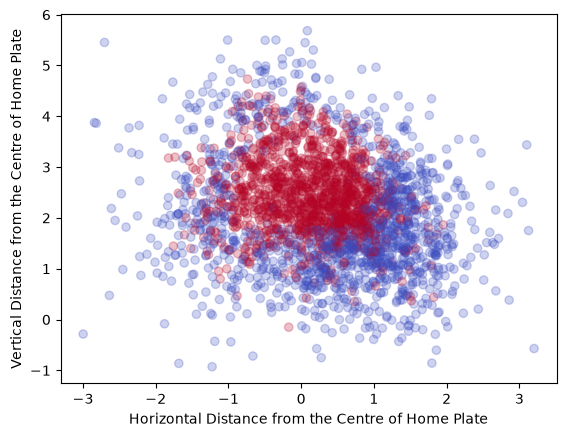

In [44]:
# 8. Plot the ball locations.
plt.scatter(x=aaron_judge['plate_x'],
            y=aaron_judge['plate_z'],
            c=aaron_judge['type'],
            cmap=plt.cm.coolwarm,
            alpha=0.25)
plt.xlabel('Horizontal Distance from the Centre of Home Plate')
plt.ylabel('Vertical Distance from the Centre of Home Plate')
plt.show()

## Build the SVM

In [45]:
# 9. Split Aaron Judge's batting data into training and validation sets.
print('Splitting batting data ...')
X_train, X_validate, y_train, y_validate = train_test_split(aaron_judge[['plate_x', 'plate_z']], aaron_judge['type'], random_state=1)

Splitting batting data ...


In [46]:
# 10. Create an SVC object.
print('Creating an SVC classifier ...')
classifier = SVC(kernel='rbf')

Creating an SVC classifier ...


In [47]:
# 11. Fit the batting data to our SVM.
print('Fitting batting data ...')
classifier.fit(aaron_judge[['plate_x', 'plate_z']], aaron_judge['type'])

Fitting batting data ...


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Producing the predicted strike zone ...


C:\Users\Michael\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


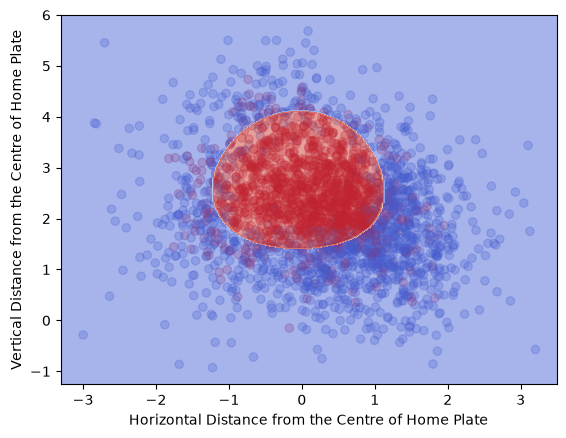

In [48]:
# 12. Visualise the SVM.
fig, ax = plt.subplots()
print('Producing the predicted strike zone ...')
plt.scatter(x=aaron_judge['plate_x'],
            y=aaron_judge['plate_z'],
            c=aaron_judge['type'],
            cmap=plt.cm.coolwarm,
            alpha=0.25)
draw_boundary(ax, classifier)
plt.xlabel('Horizontal Distance from the Centre of Home Plate')
plt.ylabel('Vertical Distance from the Centre of Home Plate')
plt.show()

## Optimise the SVM

Creating a new SVC classifier ...


C:\Users\Michael\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


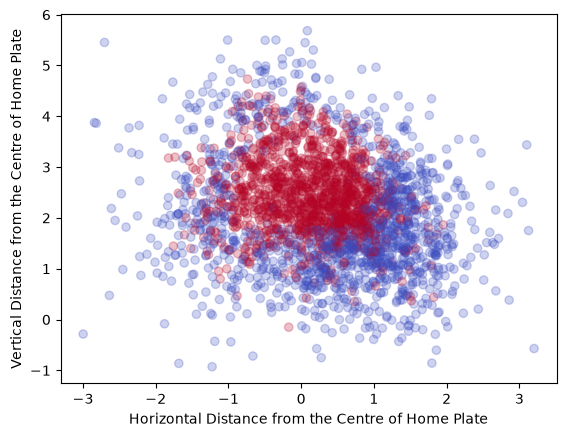

New SVM accuracy: 0.9630049075122687


In [49]:
# 14. Change the SVM's parameters to get the new decision boundary.
print('Creating a new SVC classifier ...')
classifier = SVC(kernel='rbf', gamma=100, C=100)
classifier.fit(aaron_judge[['plate_x', 'plate_z']], aaron_judge['type'])
plt.scatter(x=aaron_judge['plate_x'],
            y=aaron_judge['plate_z'],
            c=aaron_judge['type'],
            cmap=plt.cm.coolwarm,
            alpha=0.25)
draw_boundary(ax, classifier)
plt.xlabel('Horizontal Distance from the Centre of Home Plate')
plt.ylabel('Vertical Distance from the Centre of Home Plate')
plt.show()
print('New SVM accuracy:', classifier.score(aaron_judge[['plate_x', 'plate_z']], aaron_judge['type']))

In [ ]:
# 15. Look through different values of 'gamma' and 'C' and print the accuracy accordingly.
for i in range(1, 11):
  for j in range(1, 11):
    classifier = SVC(kernel='rbf', gamma=i, C=j)
    classifier.fit(aaron_judge[['plate_x', 'plate_z']], aaron_judge['type'])
    print(f'SVM accuracy at gamma={i} and C={j}:', classifier.score(aaron_judge[['plate_x', 'plate_z']], aaron_judge['type']))

In [ ]:
# 16. Create a function that takes the other players' data and produces their different strike zones.
def strike_zone(player):
    classifier = SVC(kernel='rbf', gamma=100, C=100)
    classifier.fit(player[['plate_x', 'plate_z']], player['type'])
    plt.scatter(x=player['plate_x'],
                y=player['plate_z'],
                c=player['type'],
                cmap=plt.cm.coolwarm,
                alpha=0.25)
    draw_boundary(ax, classifier)
    plt.xlabel('Horizontal Distance from the Centre of Home Plate')
    plt.ylabel('Vertical Distance from the Centre of Home Plate')
    ax.set_ylim(-2, 6)
    ax.set_xlim(-3, 3) 
    plt.show()

In [ ]:
print('Finding David Ortiz\'s strike zone ...')
strike_zone(david_ortiz)

In [ ]:
print('Finding Jose Altuve\'s strike zone ...')
strike_zone(jose_altuve)